In [1]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time

In [2]:
rootfolder = '..'

Useful function for plot a 2D dictionary

In [3]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function that implements the OMP

In [4]:
def OMP(s, D, L, tau):
    M, N = D.shape
    x_OMP = np.zeros(N)

    # residual
    r = s.copy()

    # support set
    omega = []

    while np.count_nonzero(x_OMP) < L and np.linalg.norm(r, ord=2) > tau:
        # SWEEP STEP
        # compute the residual w.r.t. each column of D
        e = np.zeros(N)
        for j in range(N):
            e[j] = (np.linalg.norm(r, ord=2) ** 2) - (r.T @ D[:, j]) ** 2

        # find the column of D that matches at best r
        jStar = np.argmin(e)

        # UPDATE the support set with the jStar coefficient
        if jStar not in omega:
            omega.append(jStar)
        else:
            break

        # update the coefficients by solving the least square problem min ||D_omega x - s||
        D_omega = D[:, omega]
        x = np.linalg.solve(D_omega.T @ D_omega, D_omega.T @ s)
        x_OMP[omega] = x

        # update the residual
        r = s - D @ x_OMP

    return x_OMP

## Dictionary Learning

Load the image and rescale it in $[0,1]$

In [5]:
path_image = f'{rootfolder}/data/barbara.png'  #  barbara.png, cameraman.png, Lena512.png

img = imread(path_image) / 255

imsz = img.shape

# patch size
p = 8

# number of elements in the patch
M = p ** 2

Extract a bunch of random patches from the image and build the training set $S$

In [6]:
npatch = 10000

S = np.zeros((M, npatch))
for i in range(npatch):
    x = np.random.randint(0, imsz[0] - p + 1)
    y = np.random.randint(0, imsz[1] - p + 1)
    patch = img[x : x+p, y : y+p].flatten()
    S[:, i] = patch

Remove the mean from the patches (each column of $S$ must have zero-mean)

In [7]:
S = S - np.mean(S, axis=0, keepdims=True)

Define a function that implements the KSVD

In [8]:
def ksvd(S, M, N, max_iter, npatch, L, print_time=False):
    # intialize the dictionary
    # init D as Normal distribution
    D = np.random.randn(M, N)
    # init D selecting N random patches from S
    # indices = np.random.choice(S.shape[1], N, replace=False)
    # D = S[:, indices]

    # normalize each column of D (zero mean and unit norm)
    D = D - np.mean(D, axis=0, keepdims=True)
    D = D / np.linalg.norm(D, axis=0, keepdims=True)

    # initialize the coefficient matrix
    X = np.zeros((N, npatch))

    # Main KSVD loop
    for iter in range(max_iter):
        time_start = time.time()

        # Sparse coding step
        # perform the sparse coding via OMP of all the columns of S
        for n in range(npatch):
            X[:, n] = OMP(S[:, n], D, L, tau=1e-6)

        # Dictionary update step
        # iterate over the columns of D
        for j0 in range(N):
            # find which signals uses the j-th atom in the sparse coding
            omega = []
            for i in range(npatch):
                if X[j0, i] != 0:
                    omega.append(i)

            if len(omega) == 0:
                # if the atom is never used then ignore or substitute it with a random vector
                D[:, j0] = np.random.randn(M)
                D[:, j0] = D[:, j0] - np.mean(D[:, j0])
                D[:, j0] = D[:, j0] / np.linalg.norm(D[:, j0])
            else:
                # compute the residual matrix E, ignoring the j-th atom
                # tot_sum = np.zeros_like(S)
                # for j in range(N):
                #     if j != j0:
                #         tot_sum += np.outer(D[:, j], X[j, :])
                # E = S - tot_sum
                # more efficient way to compute E
                E = S - D @ X + np.outer(D[:, j0], X[j0, :])

                # restrict E to the columns indicated by omega
                Eomega = E[:, omega]

                # Compute the best rank-1 approximation
                U, Sigma, Vt = np.linalg.svd(Eomega, full_matrices=False)

                # update the dictionary
                D[:, j0] = U[:, 0]

                # update the coefficient matrix
                X[j0, omega] = Sigma[0] * Vt[0, :]

        time_end = time.time()
        if print_time:
            print(f'Iteration {iter} runtime: {time_end-time_start}')

    return D

In [ ]:
# number of columns of the dictionary
N = 256

# number of iteration of the KSVD
max_iter = 10

# maximum number of nonzero coefficients for the sparse coding
L = 4

# Call the KSVD implementation
D = ksvd(S, M, N, max_iter, npatch, L, print_time=True)

Iteration 0 runtime: 44.93108797073364
Iteration 1 runtime: 57.74552655220032
Iteration 2 runtime: 43.46750831604004
Iteration 3 runtime: 76.3288996219635
Iteration 4 runtime: 163.60502195358276


KeyboardInterrupt: 

: 

Show the learned dictionary

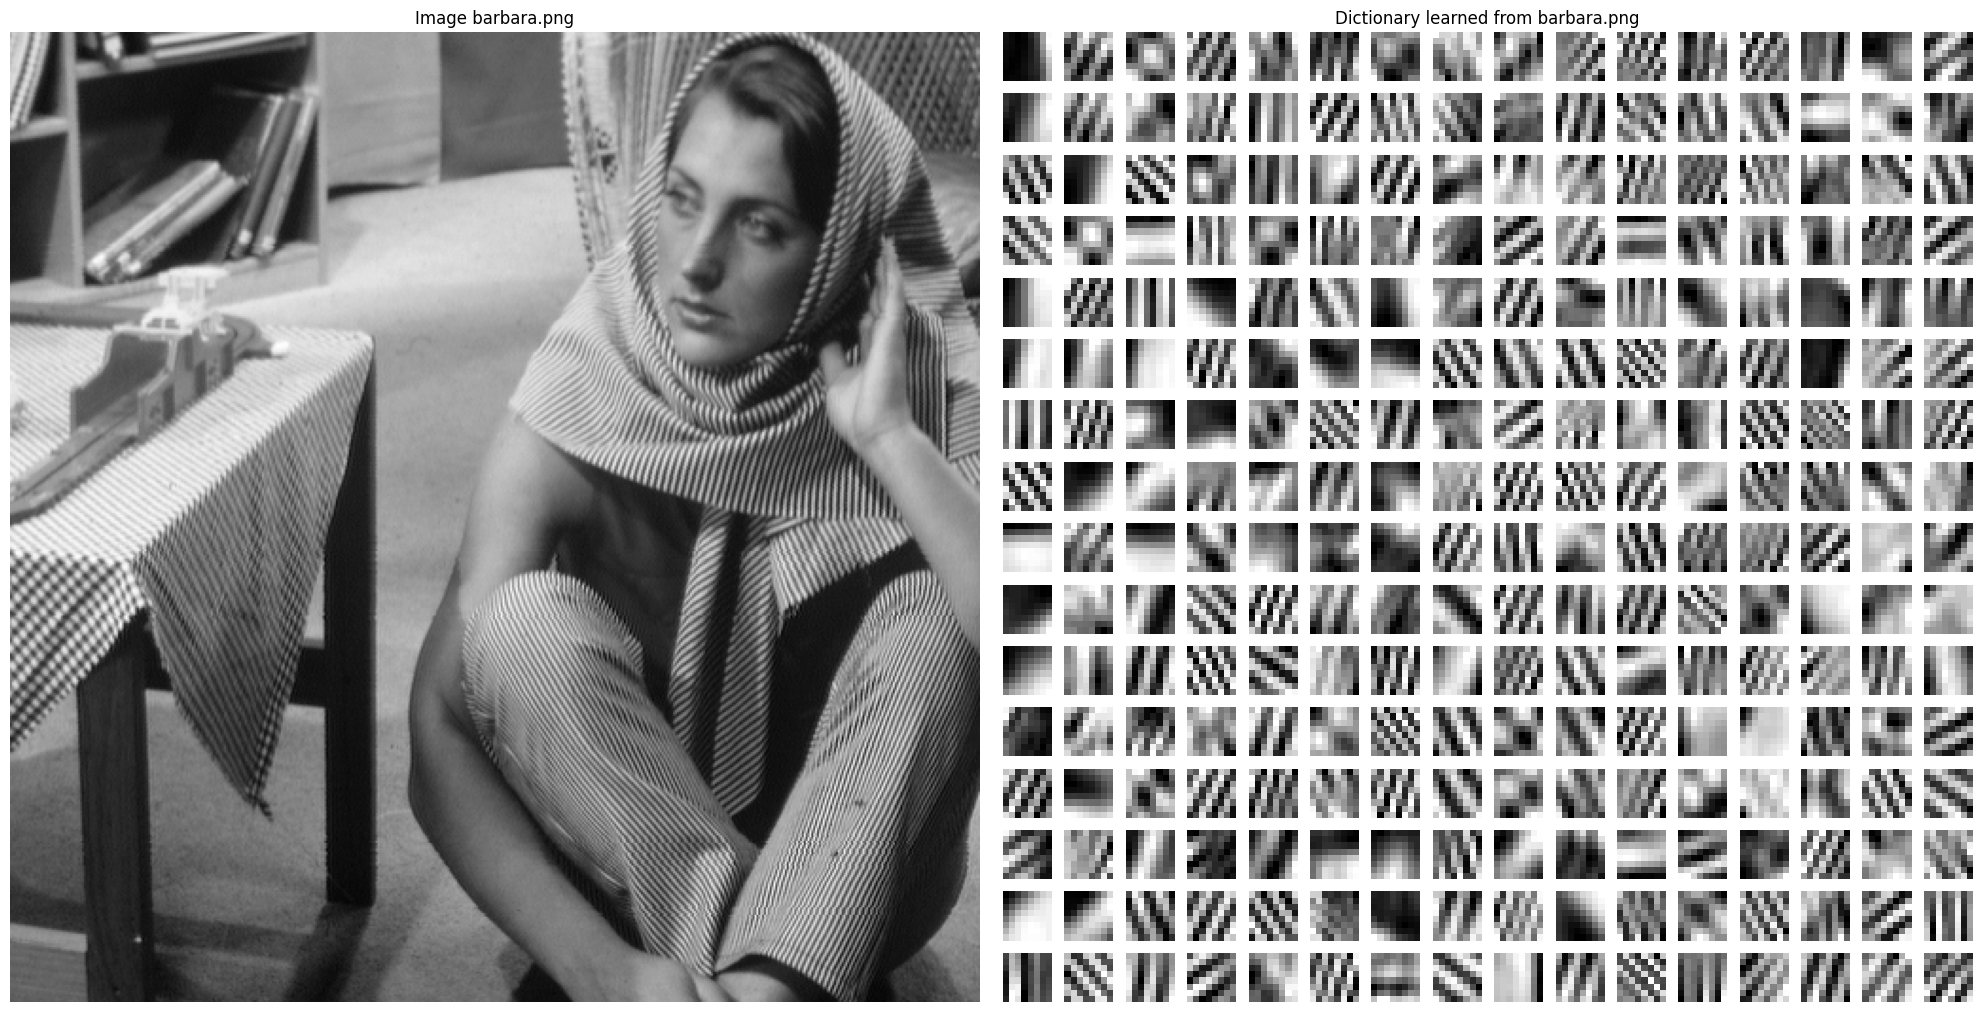

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(img, cmap='gray')
ax[0].set_title(f'Image {path_image.split("/")[-1]}')
ax[0].axis('off')

img_dict = get_dictionary_img(D)
ax[1].imshow(img_dict, cmap='gray')
ax[1].set_title(f'Dictionary learned from {path_image.split("/")[-1]}')
ax[1].axis('off')

plt.tight_layout()

## OMP denoising with learned dictionaries

In [ ]:
img_clean = imread(f'{rootfolder}/data/barbara.png') / 255

# Corrupte the image
sigma_noise = 20/255
noisy_img = img_clean + np.random.normal(size=imsz) * sigma_noise

In [ ]:
psnr_noisy = 10 * np.log10(1 / np.mean((img_clean - noisy_img)**2))

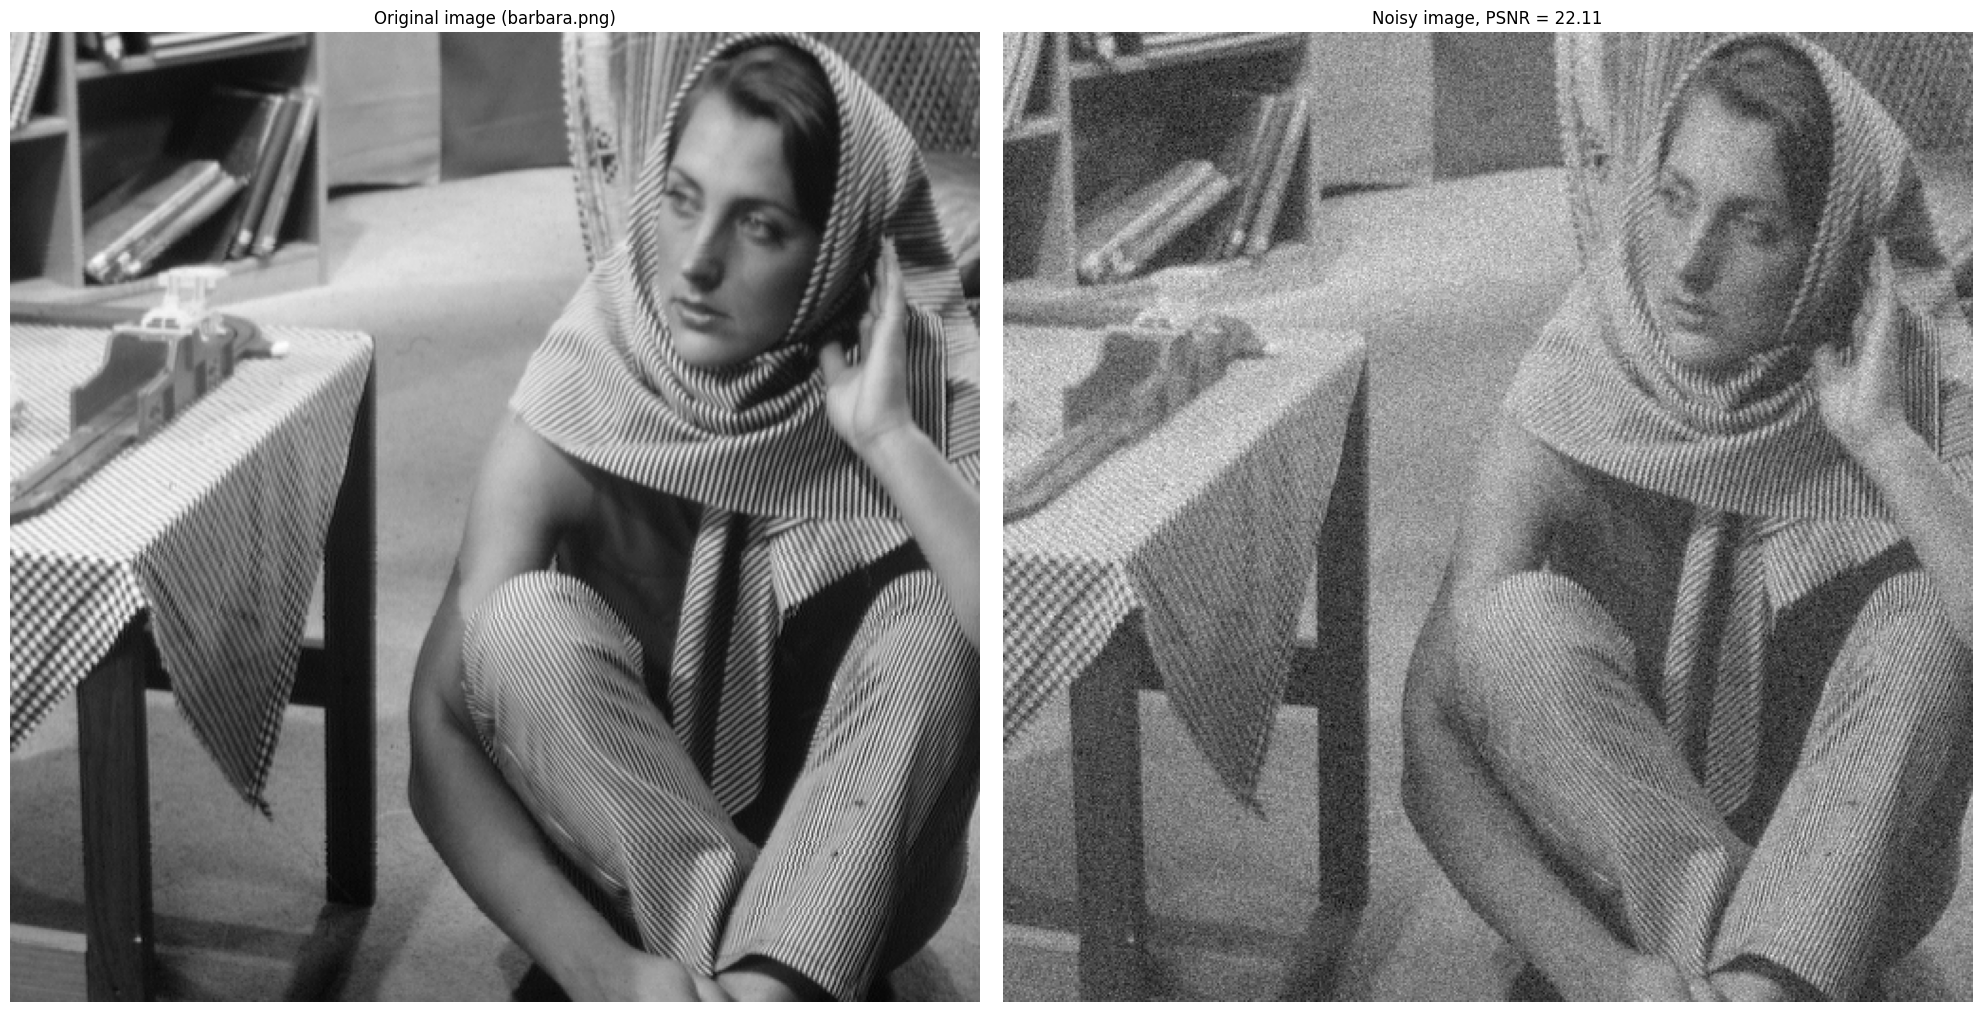

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img_clean, cmap='gray')
ax[0].set_title(f'Original image (barbara.png)')
ax[0].axis('off')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')
ax[1].axis('off')

plt.tight_layout()

In [ ]:
# patch size
p = 8

# number of elements in the patch
M = p ** 2

# number of columns of the dictionary
N = 256

# number of iteration of the KSVD
max_iter = 10

# maximum number of nonzero coefficients for the sparse coding
L = 4

Generic dictionary

In [ ]:
D_generic = loadmat(f'{rootfolder}/data/dict_nat_img.mat')['D']

Dictionary learned from a different image

In [ ]:
img = imread(f'{rootfolder}/data/cameraman.png') / 255

imsz = img.shape

# Extract random patches
npatch = 10000

S = np.zeros((M, npatch))
for i in range(npatch):
    x = np.random.randint(0, imsz[0] - p + 1)
    y = np.random.randint(0, imsz[1] - p + 1)
    patch = img[x : x+p, y : y+p].flatten()
    S[:, i] = patch
S = S - np.mean(S, axis=0, keepdims=True)

# Learn the dictionary
D_diff = ksvd(S, M, N, max_iter, npatch, L, print_time=True)

Iteration 0 runtime: 29.456576824188232
Iteration 1 runtime: 29.417949438095093
Iteration 2 runtime: 81.5825023651123
Iteration 3 runtime: 166.0766191482544
Iteration 4 runtime: 87.4749686717987
Iteration 5 runtime: 30.207135915756226
Iteration 6 runtime: 30.6024010181427
Iteration 7 runtime: 96.22860288619995
Iteration 8 runtime: 30.908188581466675
Iteration 9 runtime: 32.21626877784729


Dictionary learned from the noisy image

In [ ]:
imsz = noisy_img.shape

# Extract random patches
npatch = 10000

S = np.zeros((M, npatch))
for i in range(npatch):
    x = np.random.randint(0, imsz[0] - p + 1)
    y = np.random.randint(0, imsz[1] - p + 1)
    patch = noisy_img[x : x+p, y : y+p].flatten()
    S[:, i] = patch
S = S - np.mean(S, axis=0, keepdims=True)

# Learn the dictionary
D_noisy = ksvd(S, M, N, max_iter, npatch, L, print_time=True)

Iteration 0 runtime: 32.88894176483154
Iteration 1 runtime: 66.41308641433716
Iteration 2 runtime: 167.50030875205994
Iteration 3 runtime: 34.52202796936035
Iteration 4 runtime: 108.2929060459137
Iteration 5 runtime: 35.10599660873413
Iteration 6 runtime: 43.453192949295044
Iteration 7 runtime: 61.15992617607117
Iteration 8 runtime: 28.691259145736694
Iteration 9 runtime: 29.032448053359985


Dictionary learned from the clean image

In [ ]:
imsz = img_clean.shape

# Extract random patches
npatch = 10000

S = np.zeros((M, npatch))
for i in range(npatch):
    x = np.random.randint(0, imsz[0] - p + 1)
    y = np.random.randint(0, imsz[1] - p + 1)
    patch = img_clean[x : x+p, y : y+p].flatten()
    S[:, i] = patch
S = S - np.mean(S, axis=0, keepdims=True)

# Learn the dictionary
D_clean = ksvd(S, M, N, max_iter, npatch, L, print_time=True)

Iteration 0 runtime: 29.229573249816895
Iteration 1 runtime: 29.09849715232849
Iteration 2 runtime: 29.250346660614014
Iteration 3 runtime: 29.084506034851074
Iteration 4 runtime: 28.93234372138977
Iteration 5 runtime: 28.76035761833191
Iteration 6 runtime: 28.90770435333252
Iteration 7 runtime: 29.026621103286743
Iteration 8 runtime: 29.238359451293945
Iteration 9 runtime: 29.272205352783203


OMP denoising

In [ ]:
def omp_denoising(noisy_img, D, step, tau):
    imsz = noisy_img.shape
    img_hat = np.zeros(imsz)
    weights = np.zeros(imsz)

    for i in range(0, imsz[0] - p + 1, step):
        for j in range(0, imsz[1] - p + 1, step):
            # extrach the patch with the top left corner at pixel (ii, jj)
            s = noisy_img[i : i+p, j : j+p].flatten()

            # store and subtract the mean
            s_mean = np.mean(s)
            s = s - s_mean

            # perform the sparse coding
            x_hat = OMP(s, D, L=4, tau=tau)

            # perform the reconstruction
            s_hat = D @ x_hat

            # add back the mean
            s_hat += s_mean

            # put the denoised patch into the estimated image using uniform weights
            # UPDATE img_hat
            img_hat[i : i+p, j : j+p] += s_hat.reshape(p, p)

            # store the weight of the current patch in the weight matrix
            # UPDATE weights
            weights[i : i+p, j : j+p] += 1
    
    return img_hat / weights

Denoising using the learned dictionaries

In [ ]:
# set the threshold
tau = 1.15 * p * sigma_noise

# define the step (=p for non overlapping paches)
STEP = 4 # STEP = 1 might be very time consuming, start with larger STEP

Solve the four denoising problems

In [ ]:
# Denoising with dictionary D_generic
img_hat_generic = omp_denoising(noisy_img, D_generic, STEP, tau)

# Denoising with dictionary D_diff
img_hat_diff = omp_denoising(noisy_img, D_diff, STEP, tau)

# Denoising with dictionary D_noisy
img_hat_noisy = omp_denoising(noisy_img, D_noisy, STEP, tau)

# Denoising with dictionary D_clean
img_hat_clean = omp_denoising(noisy_img, D_clean, STEP, tau)

Visualize the results

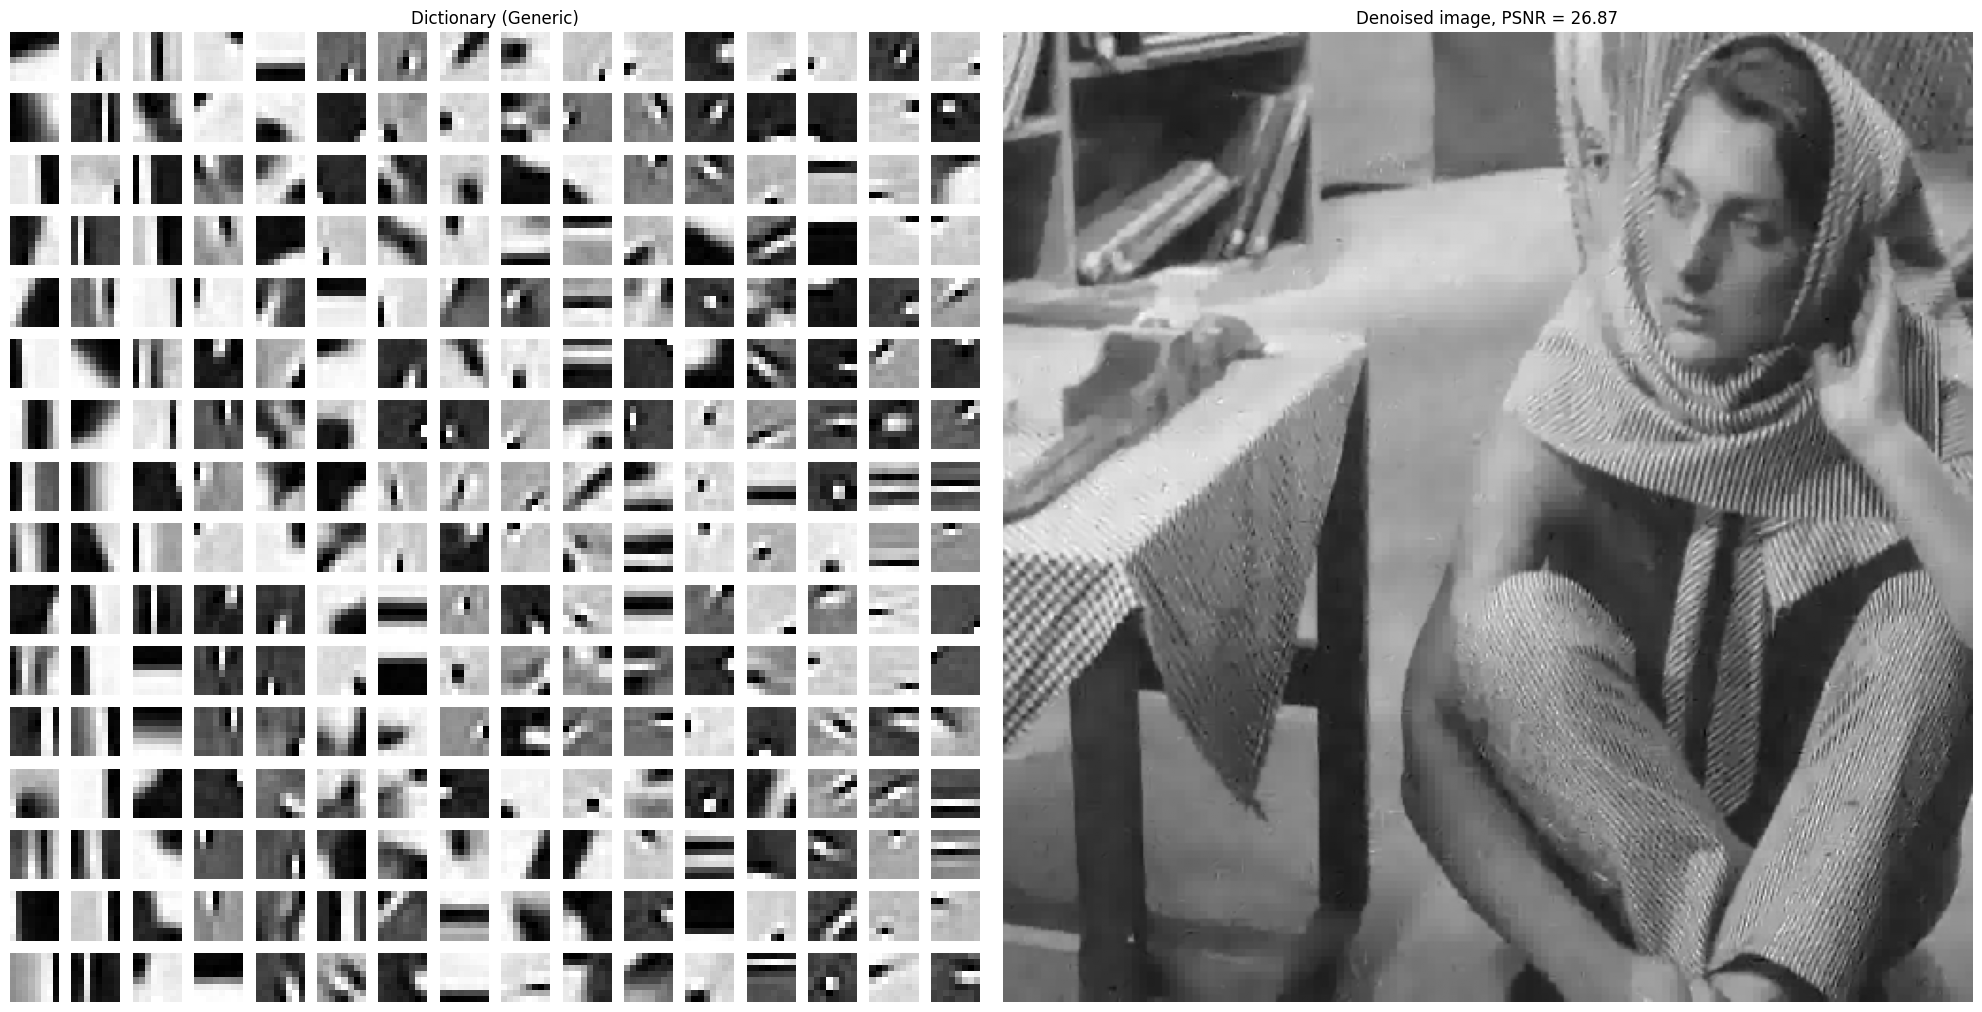

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(get_dictionary_img(D_generic), cmap='gray')
ax[0].set_title('Dictionary (Generic)')
ax[0].axis('off')

psnr_hat = 10 * np.log10(1 / np.mean((img_clean - img_hat_generic) ** 2))

ax[1].imshow(img_hat_generic, cmap='gray')
ax[1].set_title(f'Denoised image, PSNR = {psnr_hat:.2f}')
ax[1].axis('off')

plt.tight_layout()

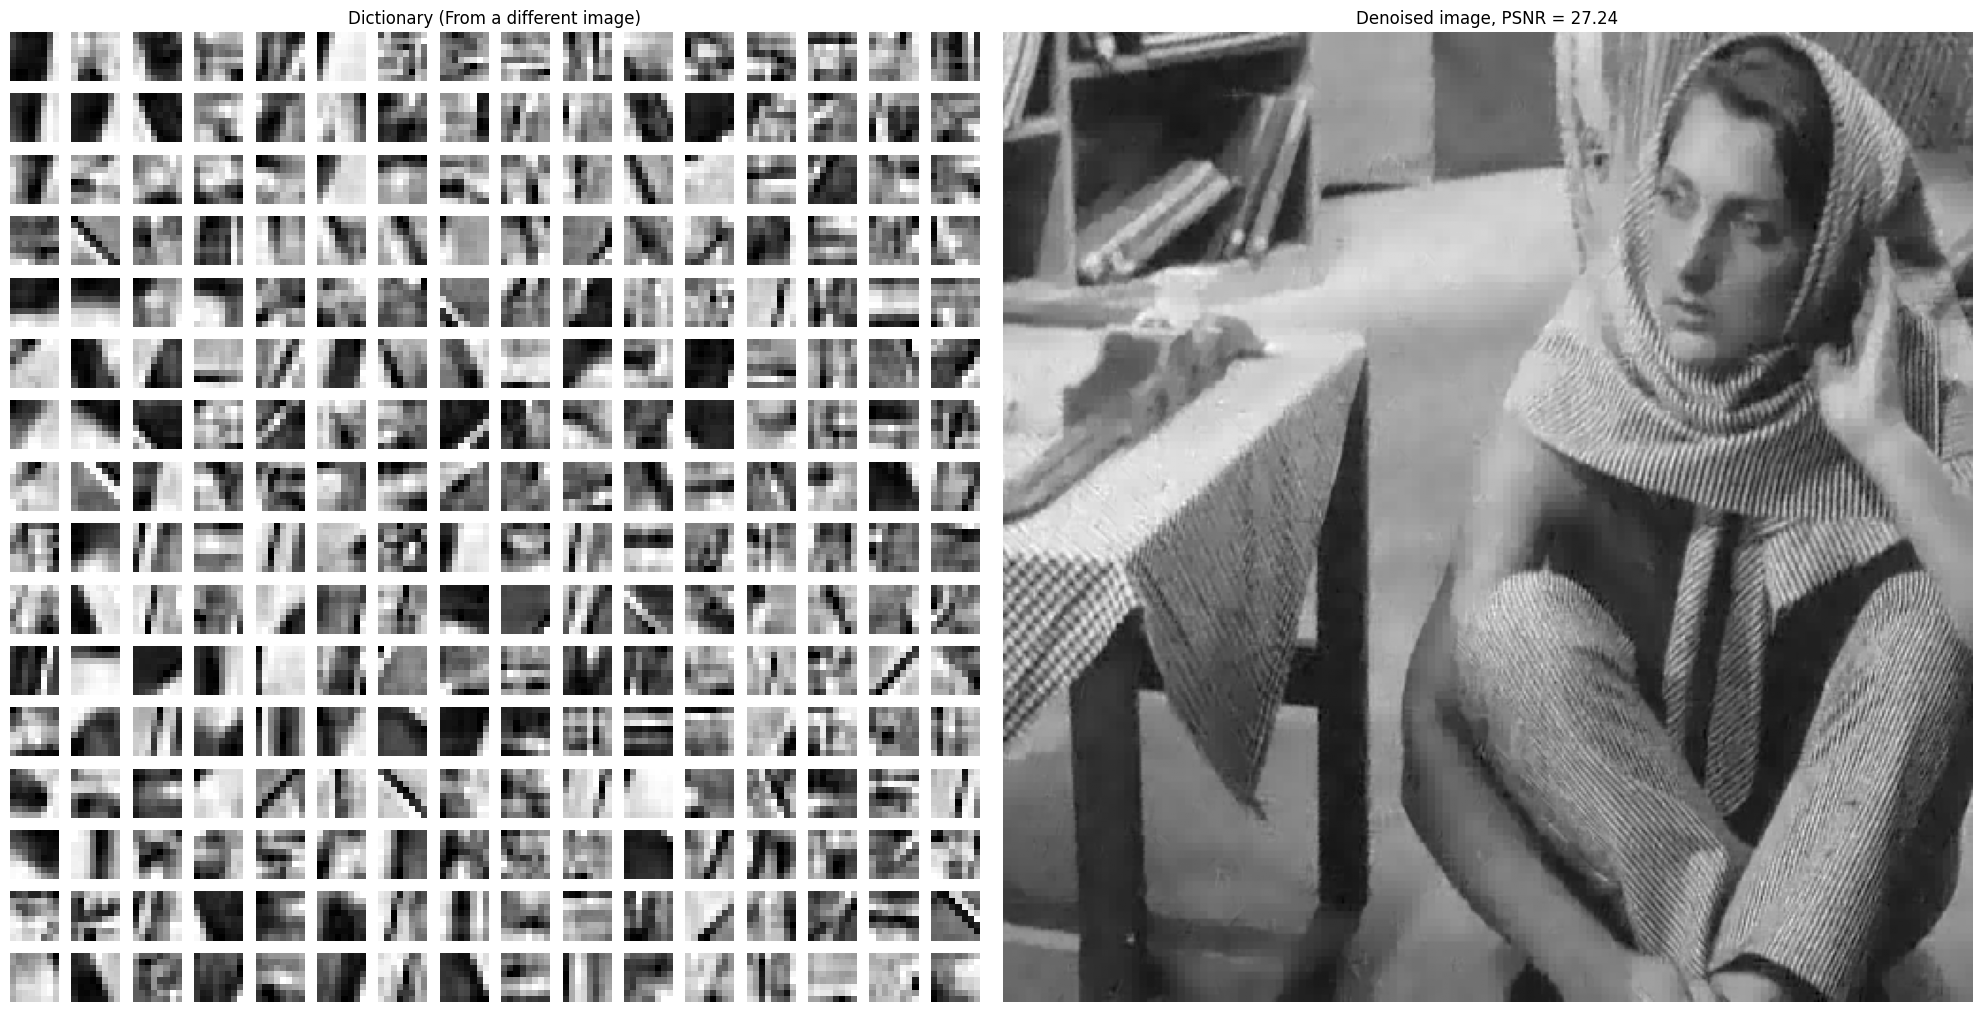

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(get_dictionary_img(D_diff), cmap='gray')
ax[0].set_title('Dictionary (From a different image)')
ax[0].axis('off')

psnr_hat = 10 * np.log10(1 / np.mean((img_clean - img_hat_diff) ** 2))

ax[1].imshow(img_hat_diff, cmap='gray')
ax[1].set_title(f'Denoised image, PSNR = {psnr_hat:.2f}')
ax[1].axis('off')

plt.tight_layout()

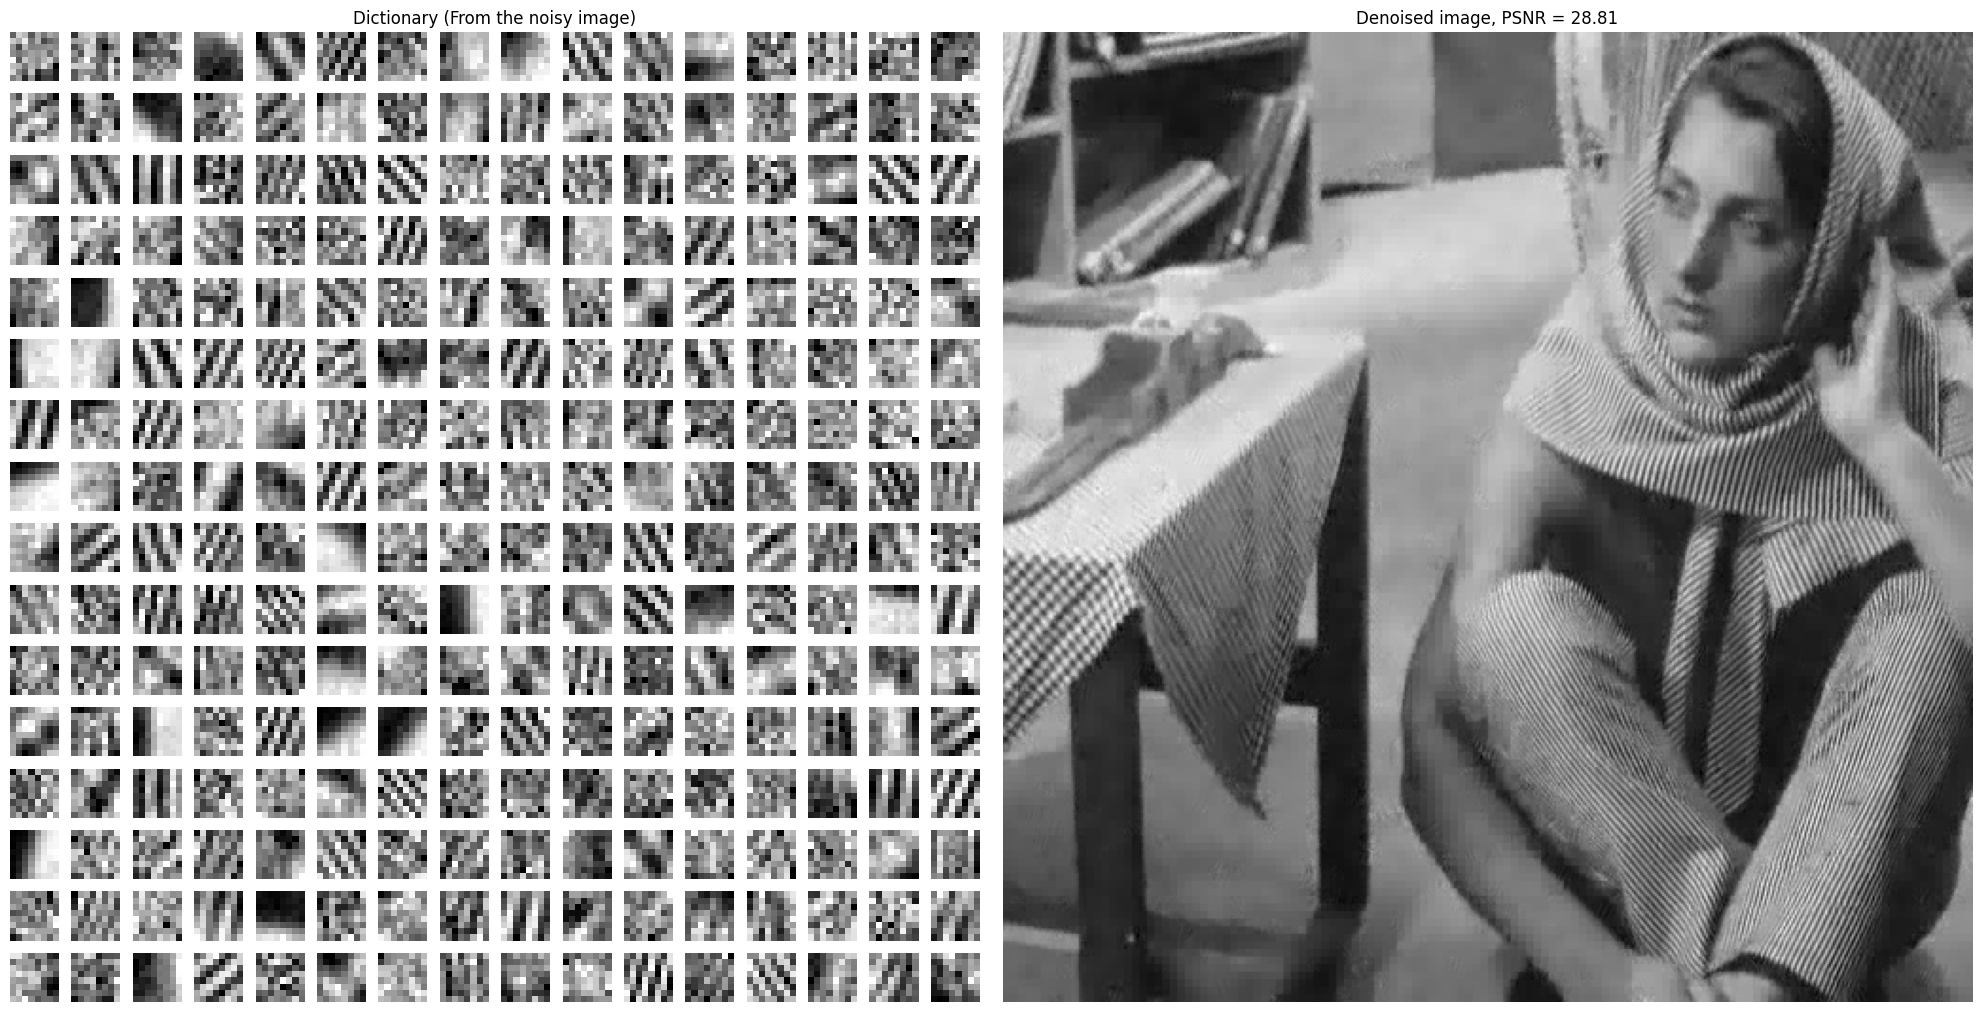

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(get_dictionary_img(D_noisy), cmap='gray')
ax[0].set_title('Dictionary (From the noisy image)')
ax[0].axis('off')

psnr_hat = 10 * np.log10(1 / np.mean((img_clean - img_hat_noisy) ** 2))

ax[1].imshow(img_hat_noisy, cmap='gray')
ax[1].set_title(f'Denoised image, PSNR = {psnr_hat:.2f}')
ax[1].axis('off')

plt.tight_layout()

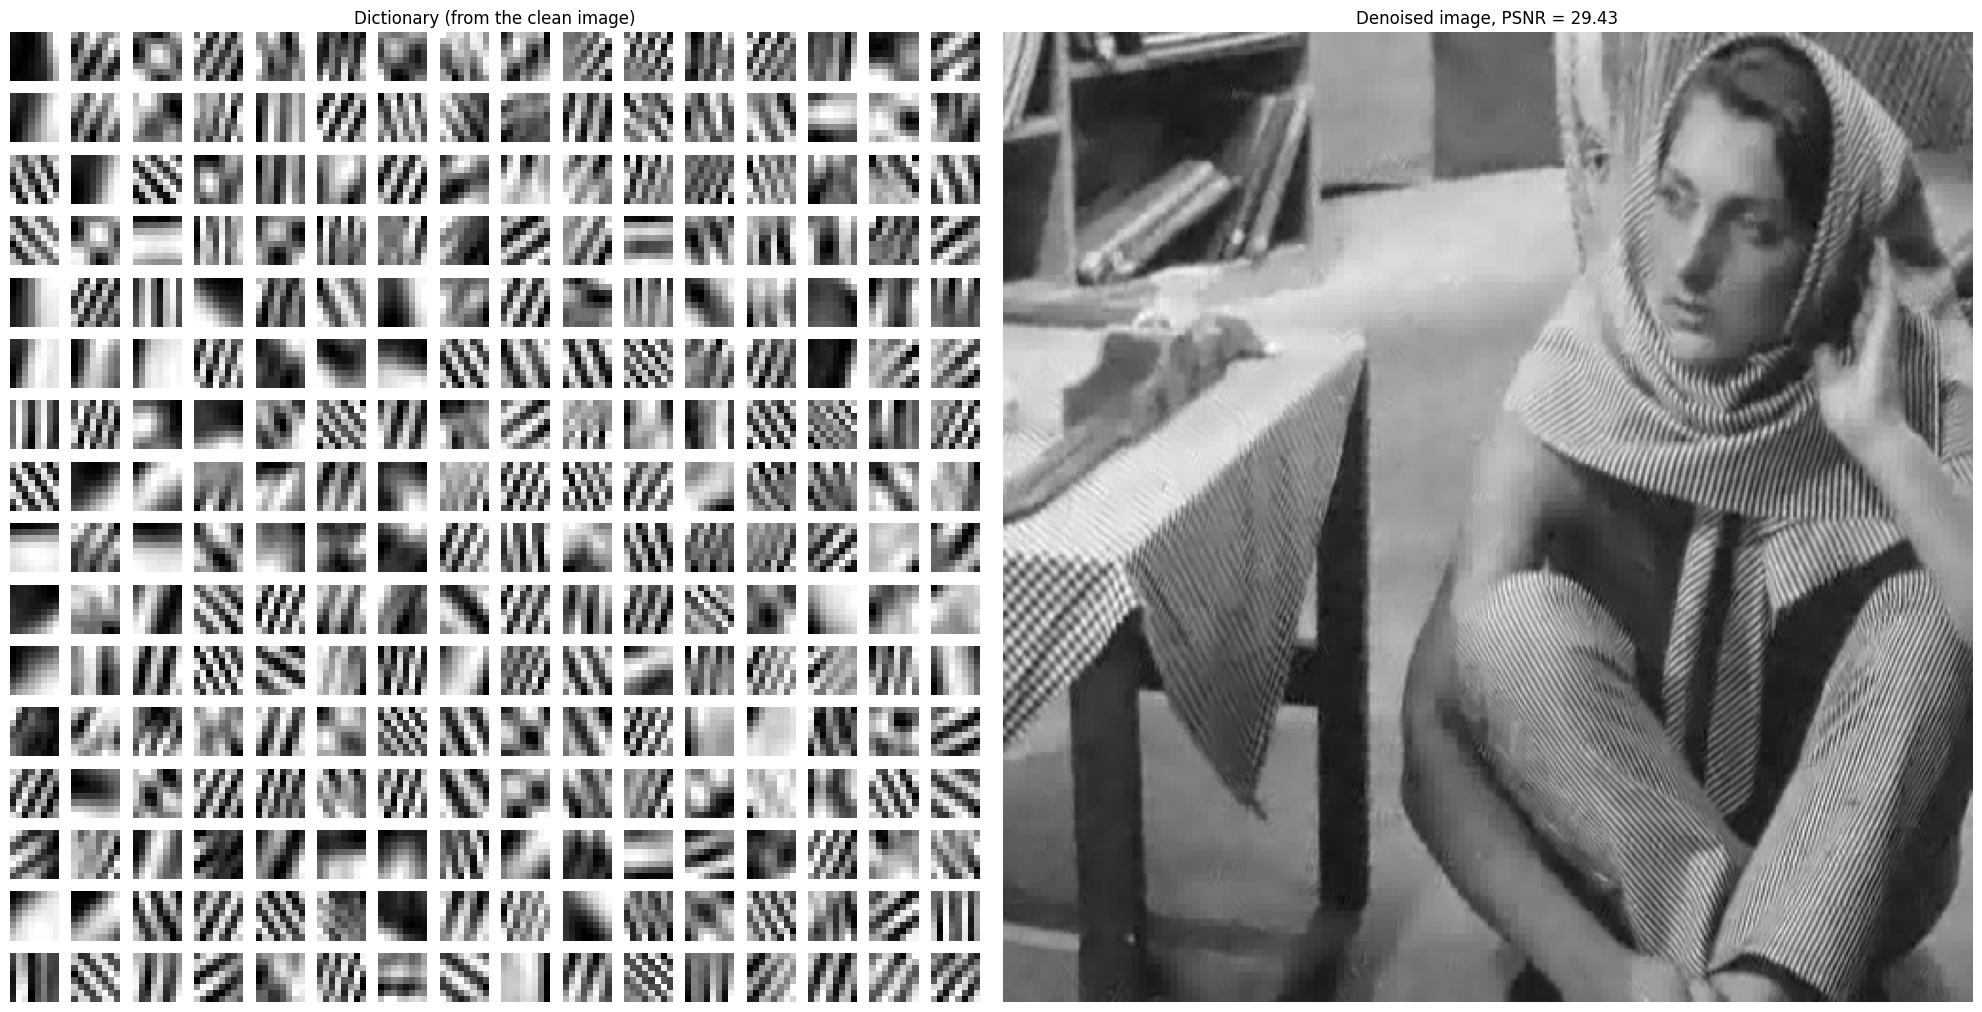

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(get_dictionary_img(D_clean), cmap='gray')
ax[0].set_title('Dictionary (from the clean image)')
ax[0].axis('off')

psnr_hat = 10 * np.log10(1 / np.mean((img_clean - img_hat_clean) ** 2))

ax[1].imshow(img_hat_clean, cmap='gray')
ax[1].set_title(f'Denoised image, PSNR = {psnr_hat:.2f}')
ax[1].axis('off')

plt.tight_layout()

# Extra Assignment 1: Learn textures
- Download few texture rich images from the [Brodatz](https://sipi.usc.edu/database/database.php) dataset
- Use KSVD to learn dictionaries from these images
- Try with different patch sizes

In [ ]:
def extract_patch(img, patch_size, index):
    imsz = img.shape
    npatch_per_row = (imsz[1] - patch_size + 1)
    x = index // npatch_per_row
    y = index % npatch_per_row
    patch = img[x : x+patch_size, y : y+patch_size].flatten()
    
    return patch

In [ ]:
img_1103 = imread(f'{rootfolder}/data/brodatz_1.1.03.tiff') / 255
imsz = img_1103.shape

patch_size = 8

M = patch_size ** 2

npatch = (imsz[0] - patch_size + 1) * (imsz[1] - patch_size + 1)

S = np.zeros((M, npatch))
for i in range(npatch):
    S[:, i] = extract_patch(img_1103, patch_size, i)

S = S - np.mean(S, axis=0, keepdims=True)

dict_1103 = ksvd(S, M, N, max_iter, npatch, L, print_time=True)

# plot the image and the dictionary
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img_1103, cmap='gray')
ax[0].set_title('Image (img_1103)')
ax[0].axis('off')
ax[1].imshow(get_dictionary_img(dict_1103), cmap='gray')
ax[1].set_title('Dictionary learned from img_1103 using patch size 8')
ax[1].axis('off')

plt.tight_layout()

Iteration 0 runtime: 1291.214138507843


KeyboardInterrupt: 

In [ ]:
patch_size = 16

M = patch_size ** 2

npatch = (imsz[0] - patch_size + 1) * (imsz[1] - patch_size + 1)

S = np.zeros((M, npatch))
for i in range(npatch):
    S[:, i] = extract_patch(img_1103, patch_size, i)

S = S - np.mean(S, axis=0, keepdims=True)

dict_1103 = ksvd(S, M, N, max_iter, npatch, L, print_time=True)

# plot the image and the dictionary
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img_1103, cmap='gray')
ax[0].set_title('Image (img_1103)')
ax[0].axis('off')
ax[1].imshow(get_dictionary_img(dict_1103), cmap='gray')
ax[1].set_title('Dictionary learned from img_1103 using patch size 16')
ax[1].axis('off')

plt.tight_layout()